<a href="https://colab.research.google.com/github/Adiel13/Proyecto_grupo3/blob/master/Atividade_1_Fundamentos_Matem%C3%A1ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MODELAGEM DA EQUAÇÃO DO CALOR EM UMA BARRA POR SÉRIES DE FOURIER

**Integrantes**

Francisleide da Silva Pires

Carlos Rafael González Alejo

Igor Schmidke Ribeiro

Libardo Rodriguez Martinez

#1.INTRODUÇÃO

O presente trabalho tem como objetivo modelar a distribuição de temperatura em uma barra metálica ao longo do tempo, utilizando a equação do calor e sua representação por séries de Fourier.

A partir de uma condição inicial de temperatura uniforme e considerando condições de contorno específicas, busca-se descrever matematicamente a evolução térmica do sistema, bem como analisar seu comportamento ao longo do tempo por meio de simulações numéricas e representações gráficas.

A implementação foi realizada em Python, no ambiente Google Colab, o que permitiu validar os resultados e visualizar a dinâmica de resfriamento da barra.

Para a implementação computacional, foram utilizadas bibliotecas voltadas ao cálculo numérico, integração e visualização gráfica a seguir destacadas:




In [ ]:
# função para integração numérica
from scipy.integrate import quad as integral
from math import *
import numpy as np
import matplotlib.pyplot as plt

##2.FORMULAÇÃO DO PROBLEMA

Considere uma barra metálica unidimensional de comprimento $L = 50 cm$, inicialmente em equilíbrio térmico, com temperatura uniforme igual a $T = 100^oC $ em toda a sua extensão.

A partir do instante inicial, as extremidades da barra são mantidas a temperatura zero, estabelecendo as seguintes condições de contorno:

$$\begin{cases}
u(0,t) = 0\\
u(L,t) = 0
\end{cases}
$$

Despreza-se o efeito das dimensões laterais (altura e largura), assumindo um modelo unidimensional.

O objetivo é determinar a função $u(x,t)$ que descreve a distribuição de temperatura ao longo da barra em função da posição e do tempo, utilizando a equação do calor e sua solução por meio de séries de Fourier, seguindo a equação:

$$u(x,t) = \frac{2}{L}\sum_{n=1}^{+\infty}\int_0^L\left[f(x)\sin\left(\frac{n\pi x}{L}\right)\right]dx \sin\left(\frac{n\pi x}{L}\right) e^{-\left(\frac{n\pi \alpha}{L}\right)^2 t}$$

###2.1.CONDIÇÕES DE CONTORNO

In [ ]:
# constantes da condição de fronteira
L = 50
T = 100
alpha = 1

###2.2.FUNÇÃO INTEGRANDO E A INTEGRAL


Define-se a função `integrando`
$$f(x)\sin\left(\frac{n\pi x}{L}\right)$$
separadamente para facilitar so cálculo dos coeficientes da série de Fourier, considerando que $f(x)=T$, visto que a temperatura da barra é constante e uniforme no instante $t=0$

In [ ]:
def integrando(x, n):
    return T * sin(n * pi * x / L)

Em seguida, definimos a função `F(n)` como a integral do integrando no intervalo de 0 a L.

In [ ]:
def F(n):
    return integral(lambda x: integrando(x, n), 0, L)[0]

###2.3.CONSTRUÇÃO DO SOMATÓRIO

A solução da equação do calor é representada como uma soma de termos da série de Fourier. Para fins computacionais, o somatório infinito é aproximado por um número finito de termos.

In [ ]:
def somatorio(f, a, N=100):
    soma = 0
    for n in range(a, N+1):
        soma += f(n)
    return soma


###2.4.DEFINIÇÃO DA FUNÇÃO $u(x,t)$

A função $u(x,t)$ representa a distribuição de temperatura ao longo da barra e é construída a partir dos coeficientes de Fourier e de sua evolução no tempo.

In [ ]:
def u(x, t):
    return 2/L * somatorio(
        lambda n: F(n) * np.sin((n * np.pi / L) * x) * np.exp(-(n * np.pi * alpha/ L)**2 * t),
        1
    )

###2.5.VALIDAÇÃO DA FUNÇÃO

A função $u(x,t)$ é avaliada em um ponto específico com o objetivo de verificar seu comportamento em relação à condição inicial do problema.

In [ ]:
u(25, 0)

np.float64(99.36344385781773)

##3.ANÁLISE GRÁFICA DO MODELO


Apresentamos a evolução da distribuição de temperatura ao longo da barra para diferentes instantes de tempo, o que permite observar o processo de resfriamento do sistema. Inicialmente consideramos que $\alpha = 1$:

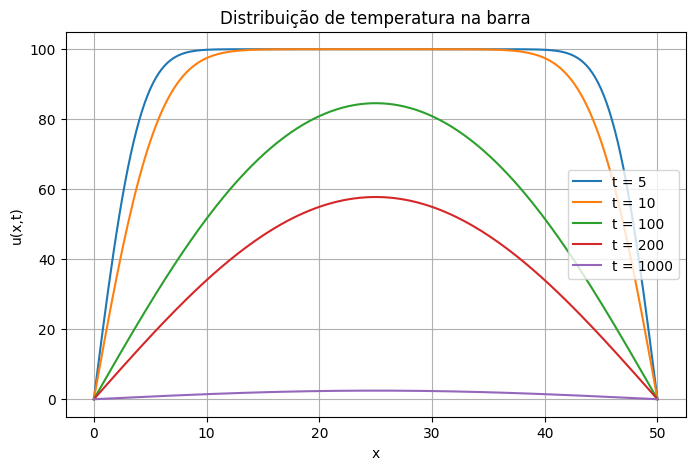

In [ ]:
def grafico():
  # valores de x
  x_vals = np.linspace(0, L, 200)

  # tempos que queremos visualizar
  tempos = [ 5, 10,100, 200,1000]

  # plot
  plt.figure(figsize=(8,5))

  for t in tempos:
      y = [u(x, t) for x in x_vals]
      plt.plot(x_vals, y, label=f"t = {t}")

  plt.xlabel("x")
  plt.ylabel("u(x,t)")
  plt.title("Distribuição de temperatura na barra")
  plt.legend()
  plt.grid()

  plt.show()

grafico()

Com objetivo investigativo, alteramos o coeficiente $\alpha$ para 2, obtendo a seguinte família de gráficos.

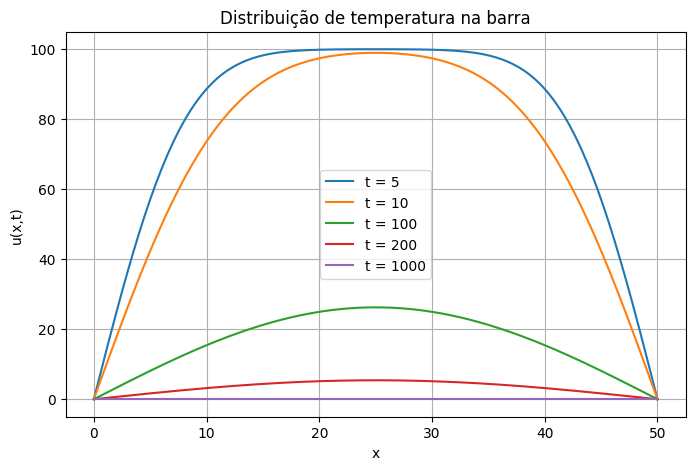

In [ ]:
alpha = 2
grafico()

##4. PAPEL DO COEFICIENTE $\alpha$ NA EQUAÇÃO

Na equação de difusão de calor, o parâmetro $α$ representa a *difusividade térmica* do material. Esta grandeza física descreve **quão rapidamente o calor se propaga dentro de um meio**. Fisicamente, $α$ considera a capacidade de um material de responder a variações de temperatura.
Ele combina dois efeitos fundamentais:

- **Condução de calor**: quão bem o material transmite energia térmica
- **Armazenamento de calor**: quanta energia o material consegue armazenar

De acordo com Lightfoot (1960), matematicamente o coeficiente segue a lei:

$$\alpha = \frac{k}{\rho c_p}$$

onde:
- $k$: condutividade térmica
- $\rho$: densidade do material
- $c_p$: calor específico



##5.CONCLUSÃO



Este trabalho permitiu compreender e descrever a evolução da temperatura em uma barra ao longo do tempo, a partir da aplicação da equação do calor e de sua solução através da séries de Fourier.

A modelagem adotada mostrou-se adequada para representar o fenômeno físico, evidenciando como as condições iniciais e de contorno influenciam diretamente o comportamento térmico do sistema.
Os gráficos obtidos reforçam de forma clara a consistência do modelo matemático adotado para descrever a difusão de calor na barra. A partir das simulações, observa-se que, nos instantes iniciais (como $t=5$ e $t=10$), a temperatura no interior da barra permanece próxima de $100^∘C$, enquanto as extremidades, submetidas à condição de contorno nula, apresentam queda acentuada.
Com o passar do tempo ($t=100$ e $t=200$), nota-se uma diminuição  da temperatura em toda a extensão da barra, acompanhada de uma suavização da curva, indicando a dissipação progressiva do calor. Além disso, nota-se que ao aumentar o valor da constante $\alpha$ (coeficiente de difusão térmica) de $\alpha=1$ para $\alpha=2$, ocorre uma aceleração no processo de dissipação de calor ao longo da barra.




## 6. REFERÊNCIAS

DIFUSIVIDADE Térmica. Em Wikipédia: a enciclopédia livre. Wikimedia, 2006. Disponível em: https://pt.wikipedia.org/wiki/Difusividade_t%C3%A9rmica. Acesso em 30/03/2026.

EQUAÇÃO do Calor. Em Wikipédia: a enciclopédia livre. Wikimedia, 2006. Disponível em: https://pt.wikipedia.org/wiki/Equa%C3%A7%C3%A3o_do_calor. Acesso em 26/03/2026.